In [1]:
import pandas as pd
import numpy as np


1. Viết hàm load_data() để tải dữ liệu lên ứng dụng. Sau đó, hiển thị ra màn hình 10 dòng
đầu tiên.

In [2]:
df = pd.read_csv(
    "titanic_disaster.csv",
    on_bad_lines='skip'
)
df.head(10)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


2. Thống kê dữ liệu thiếu trên các biến số và trực quan hóa dữ liệu thiếu bằng biểu đồ (Heat
map). Hãy cho nhận xét về tình trạng thiếu dữ liệu Age, Cabin và Embarked

In [3]:
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Values": missing_count,
    "Percent (%)": missing_percent
})

print(missing_table.sort_values(by="Missing Values", ascending=False))


             Missing Values  Percent (%)
Cabin                   687    77.104377
Age                     177    19.865320
Embarked                  2     0.224467
PassengerId               0     0.000000
Name                      0     0.000000
Pclass                    0     0.000000
Survived                  0     0.000000
Sex                       0     0.000000
Parch                     0     0.000000
SibSp                     0     0.000000
Fare                      0     0.000000
Ticket                    0     0.000000


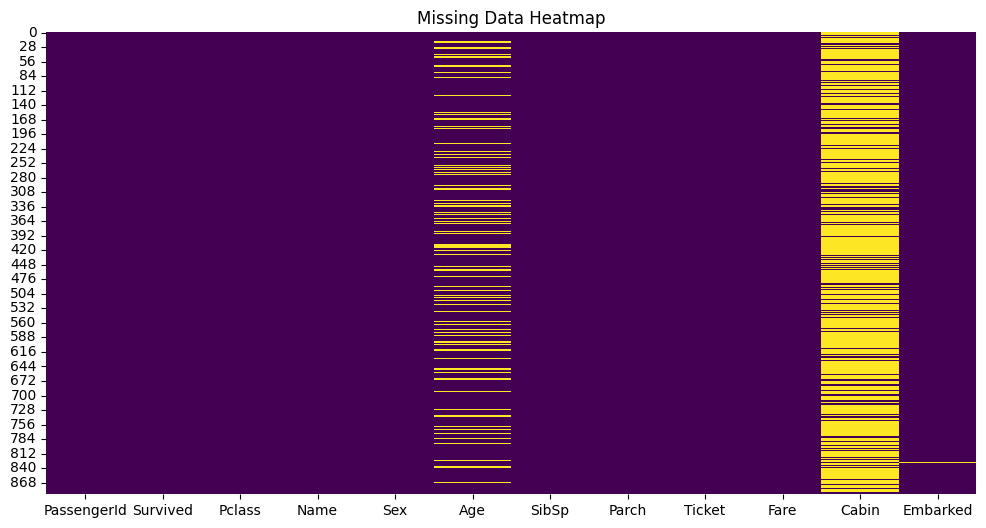

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Data Heatmap")
plt.show()

3. Xử lý tên cột tên Name, tách ra làm 2 cột: firstName và secondName. Lưu ý: Sau khi
tách cột xong thì xóa luôn cột Name

In [5]:
# Tách LastName
df[['LastName', 'Rest']] = df['Name'].str.split(',', n=1, expand=True)

# Tách Title và FirstName
df[['Title', 'FirstName']] = df['Rest'].str.split('.', n=1, expand=True, regex=False)

# Làm sạch
df['LastName'] = df['LastName'].str.strip()
df['Title'] = df['Title'].str.strip()
df['FirstName'] = df['FirstName'].str.strip()

# Xóa cột thừa
df.drop(['Name', 'Rest'], axis=1, inplace=True)

print(df.head())


   PassengerId  Survived  Pclass     Sex   Age  SibSp  Parch  \
0            1         0       3    male  22.0      1      0   
1            2         1       1  female  38.0      1      0   
2            3         1       3  female  26.0      0      0   
3            4         1       1  female  35.0      1      0   
4            5         0       3    male  35.0      0      0   

             Ticket     Fare Cabin Embarked   LastName Title  \
0         A/5 21171   7.2500   NaN        S     Braund    Mr   
1          PC 17599  71.2833   C85        C    Cumings   Mrs   
2  STON/O2. 3101282   7.9250   NaN        S  Heikkinen  Miss   
3            113803  53.1000  C123        S   Futrelle   Mrs   
4            373450   8.0500   NaN        S      Allen    Mr   

                               FirstName  
0                            Owen Harris  
1  John Bradley (Florence Briggs Thayer)  
2                                  Laina  
3          Jacques Heath (Lily May Peel)  
4              

4. Xứ lý rút gọn kích thước dữ liệu trên cột Sex như sau: thay thế male → M và female → F

In [6]:
df['Sex'] = df['Sex'].replace({
    'male': 'M',
    'female': 'F'
})


5. Xử lý dữ liệu thiếu trên biến Age bằng cách thay thế bằng giá trị trung bình tuổi: Hãy đưa
ra quyết định dùng giá trị trung bình tuổi toàn bộ hành khách hay theo từng nhóm hạng
vé (hạng hành khách: Pclass). Ta tiến hành làm các bước sau

a. Sử dụng Seaborn để vẽ biểu đồ (Box plot) trực quan dữ liệu để xác định phân
phối tuổi trên từng hạng hành khách. Nhận xét về tuổi trung bình giữa các nhóm
hành khách. Từ đó đưa ra quyết định cách thay thế giá trị tuổi bị thiếu.

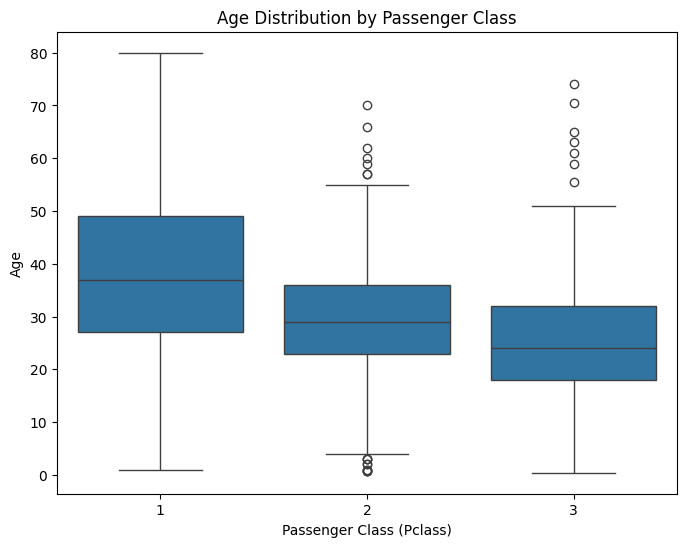

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.boxplot(x='Pclass', y='Age', data=df)
plt.title("Age Distribution by Passenger Class")
plt.xlabel("Passenger Class (Pclass)")
plt.ylabel("Age")
plt.show()


b. Tiến hành thay thế giá trị Age bị thiếu. Sau đó, hiển thị kết quả dạng bảng và trực
quan dữ liệu đã xử lý thiếu cho cột’Age’ bằng biểu đồ Heat map.

In [8]:
df['Age'] = df.groupby('Pclass')['Age'].transform(
    lambda x: x.fillna(x.median())
)


In [9]:
age_missing = df['Age'].isnull().sum()
print("Số giá trị Age còn thiếu:", age_missing)

Số giá trị Age còn thiếu: 0


In [10]:
print(df[['Pclass','Age']].groupby('Pclass').describe())

          Age                                                      
        count       mean        std   min    25%   50%    75%   max
Pclass                                                             
1       216.0  38.062130  13.737970  0.92  29.00  37.0  47.25  80.0
2       184.0  29.825163  13.575362  0.67  23.00  29.0  36.00  70.0
3       491.0  24.824684  10.632997  0.42  20.25  24.0  29.00  74.0


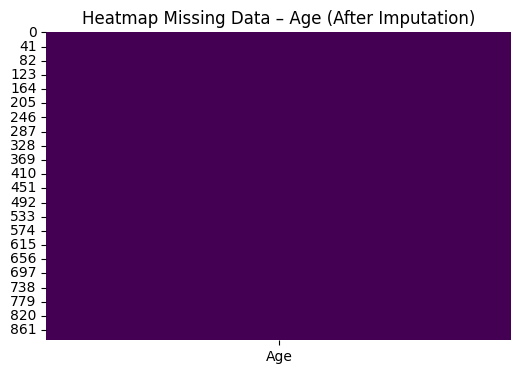

In [12]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['Age']].isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap Missing Data – Age (After Imputation)')
plt.show()


6. Xây dựng biến số Agegroup có thang đo thứ tự được ánh xạ theo thang đo khoảng dựa
trên độ tuổi của hành khách như sau: (age =< 12] → Kid; (12, 18]: Teen, (18, 60]: Adult
và ( age > 60): Older

In [13]:
bins = [0, 12, 18, 60, 200]
labels = ['Kid', 'Teen', 'Adult', 'Older']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

display(df[['Age', 'AgeGroup']].head())

,Age,AgeGroup
0,22.0,Adult
1,38.0,Adult
2,26.0,Adult
3,35.0,Adult
4,35.0,Adult


7. Tiến hành thêm đặc trưng về danh xưng (namePrefix) trong xã hội bằng cách tách  Mr,
Mrs, Miss, Master ra khỏi “secondName” *italicized text*

In [14]:
df['namePrefix'] = df['Title']

# Group less common titles into 'Other'
common_titles = ['Mr', 'Mrs', 'Miss', 'Master']
df['namePrefix'] = df['namePrefix'].apply(lambda x: x if x in common_titles else 'Other')

print(df[['Title', 'namePrefix']].head(10))
print('\nValue counts for namePrefix:')
print(df['namePrefix'].value_counts())

    Title namePrefix
0      Mr         Mr
1     Mrs        Mrs
2    Miss       Miss
3     Mrs        Mrs
4      Mr         Mr
5      Mr         Mr
6      Mr         Mr
7  Master     Master
8     Mrs        Mrs
9     Mrs        Mrs

Value counts for namePrefix:
namePrefix
Mr        517
Miss      182
Mrs       125
Master     40
Other      27
Name: count, dtype: int64


8. Khai thác thêm thông tin số lượng thành viên đi theo nhóm thân quen (familySize) đối
với mỗi hành khách trên chuyến hải trình; family size = 1+ SibSp + Parch

In [15]:
df['familySize'] = 1 + df['SibSp'] + df['Parch']
display(df[['SibSp', 'Parch', 'familySize']].head())

,SibSp,Parch,familySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


9. Tạo thêm đặc trưng ‘Alone’ để xác định hành khách đi theo nhóm hay cá nhân bằng cách
dựa trên familySize như sau: Nếu familySize = 0 thì giá trị Alone = 1 và ngược lại là 0.

In [16]:
df['Alone'] = df['familySize'].apply(lambda x: 1 if x == 0 else 0)
display(df[['familySize', 'Alone']].head())

,familySize,Alone
0,2,0
1,2,0
2,1,0
3,2,0
4,1,0


10. Tiến hành tách loại cabin (typeCabin) mà hành khách ở để lọc và phân tích đặc tính
cabin. Loại cabin được kí hiệu bởi chữ cái đầu tiên. Lưu ý: Đối với dữ liệu cabin bị thiếu
thì thay thế bằng “Unknown”

In [17]:
df['typeCabin'] = df['Cabin'].fillna('Unknown').apply(lambda x: x[0])
display(df[['Cabin', 'typeCabin']].head())

,Cabin,typeCabin
0,NaN,U
1,C85,C
2,NaN,U
3,C123,C
4,NaN,U


PHẦN 2: KHAI THÁC THÔNG TIN HỮU ÍCH – EDA

12. Trực quan thông tin tương quan tỉ lệ sống sót và thiệt mạng trên từng nhóm giới tính.

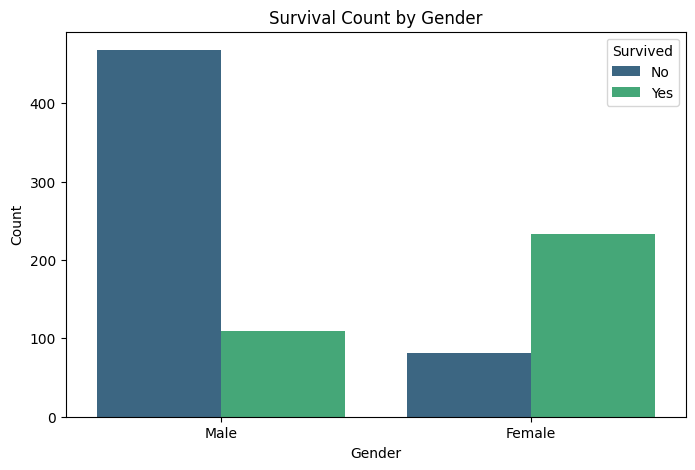

In [18]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Sex', hue='Survived', data=df, palette='viridis')
plt.title('Survival Count by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Male', 'Female'])
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

13. Trực quan thông tin hành khách sống sót trên từng nhóm phân loại hành khách (Pclass).

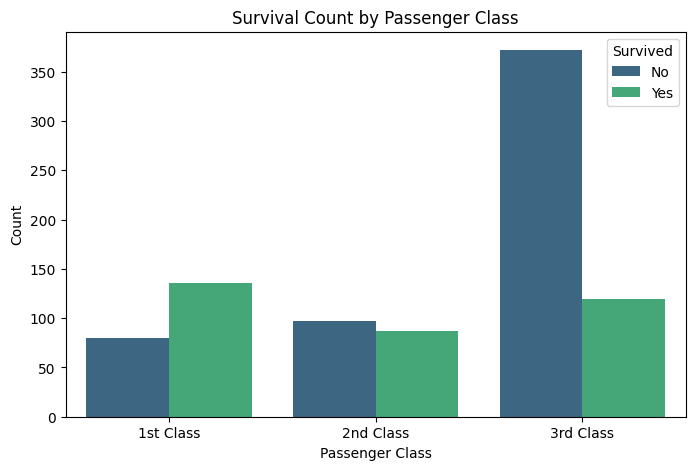

In [19]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Pclass', hue='Survived', data=df, palette='viridis')
plt.title('Survival Count by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1, 2], labels=['1st Class', '2nd Class', '3rd Class'])
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

14. Trực quan thông tin hành khách sống sót trên từng nhóm giới tính và thang đo tuổi tác

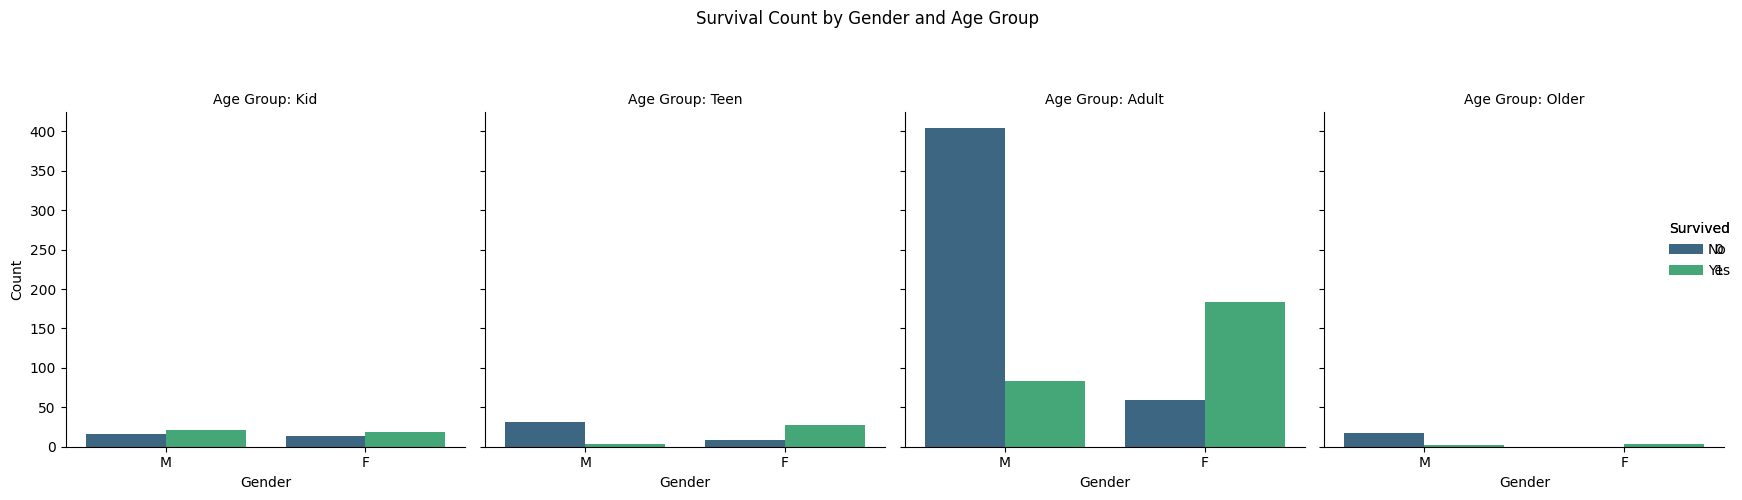

In [21]:
g = sns.catplot(x='Sex', hue='Survived', col='AgeGroup', data=df, kind='count', palette='viridis', height=5, aspect=0.8)
g.set_axis_labels("Gender", "Count")
g.set_titles("Age Group: {col_name}")
g.add_legend(title='Survived', labels=['No', 'Yes'])
plt.suptitle('Survival Count by Gender and Age Group', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

15. Trực quan xác suất hành khách sống sót dựa trên thông tin nhóm đi cùng

/tmp/ipython-input-3700678690.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='familySize', y='Survived', data=survival_rate_family, palette='viridis')


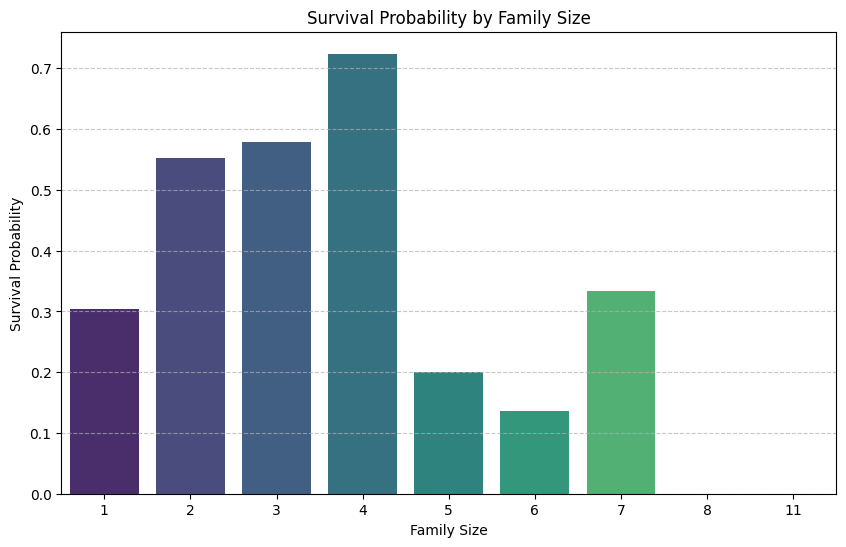

In [22]:
survival_rate_family = df.groupby('familySize')['Survived'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='familySize', y='Survived', data=survival_rate_family, palette='viridis')
plt.title('Survival Probability by Family Size')
plt.xlabel('Family Size')
plt.ylabel('Survival Probability')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

16. Trực quan xác suất hành khách sống sót dựa trên thông tin giá vé

/tmp/ipython-input-635886469.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_rate_fare = df.groupby('FareGroup')['Survived'].mean().reset_index()
/tmp/ipython-input-635886469.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='FareGroup', y='Survived', data=survival_rate_fare, palette='viridis')


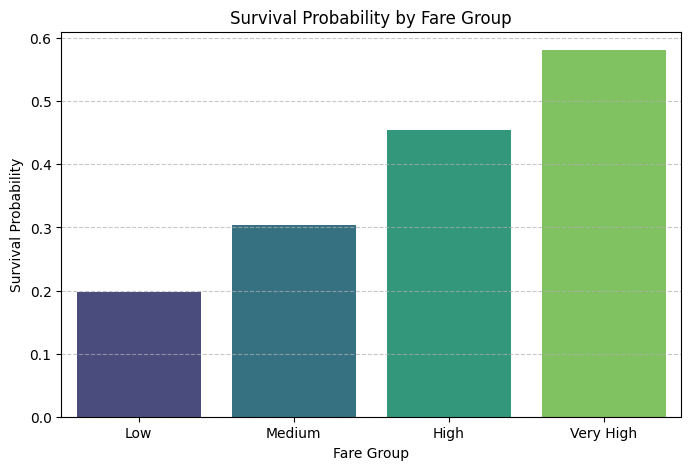

In [23]:
df['FareGroup'] = pd.qcut(df['Fare'], 4, labels=['Low', 'Medium', 'High', 'Very High'])

survival_rate_fare = df.groupby('FareGroup')['Survived'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(x='FareGroup', y='Survived', data=survival_rate_fare, palette='viridis')
plt.title('Survival Probability by Fare Group')
plt.xlabel('Fare Group')
plt.ylabel('Survival Probability')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

17. Trực quan số lượng người thiệt mạng và sống sót theo phân lớp (Pclass) hành khách và
cảng sẽ cập bến.

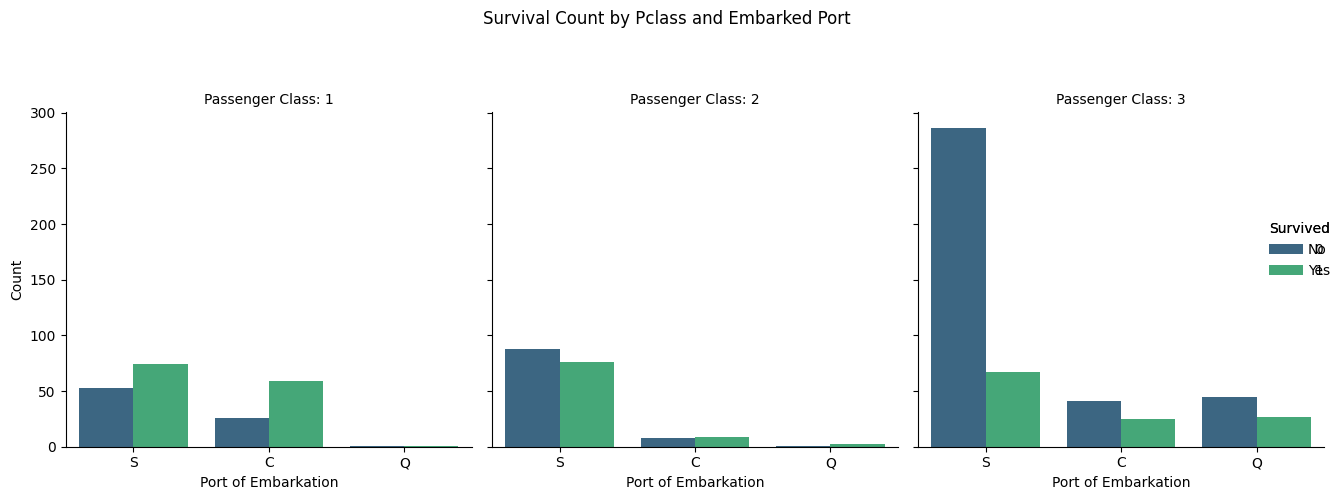

In [24]:
g = sns.catplot(x='Embarked', hue='Survived', col='Pclass', data=df, kind='count', palette='viridis', height=5, aspect=0.8)
g.set_axis_labels("Port of Embarkation", "Count")
g.set_titles("Passenger Class: {col_name}")
g.add_legend(title='Survived', labels=['No', 'Yes'])
plt.suptitle('Survival Count by Pclass and Embarked Port', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()